# Notebook 02: Feature Selection and Baseline Regression Model

## 1. Project Context
Following the initial data aggregation from Notebook 01, this stage focuses on enriching our institutional dataset with socioeconomic variables. We will identify the strongest predictors of medical course performance and train a **Linear Regression** model to calculate the expected performance of institutions, providing a comparative analysis for **UFJF**.

## 2. Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

PROCESSED_PATH = '../data/processed/'
RAW_PATH = '../data/raw/'

df_base = pd.read_csv(os.path.join(PROCESSED_PATH, 'enamed_2025_aggregated_performance.csv'))
print(f"Base dataset loaded with {df_base.shape[0]} courses.")

Base dataset loaded with 350 courses.


## 3. Socioeconomic Feature Integration

In [7]:
filename = 'microdados_enade_2025_arq3.txt'
df_arq3 = pd.read_csv(os.path.join(RAW_PATH, filename), sep=';', decimal='.')

df_present = df_arq3[df_arq3['TP_PR_GER'] == 555].copy()

area_cols = [col for col in df_present.columns if 'ACERTO' in col or 'NU_ITEM' in col]

df_areas_agregado = df_present.groupby('CO_CURSO')[area_cols].mean().reset_index()

df_ml = pd.merge(df_base, df_areas_agregado, on='CO_CURSO', how='inner')
df_ml = df_ml.fillna(df_ml.median(numeric_only=True))
print(f"Enriched dataset shape with medical areas: {df_ml.shape}")

Enriched dataset shape with medical areas: (350, 12)


## 4. Feature Selection via Correlation Analysis

c:\Users\lucas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\lucas\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\lucas\AppData\Local\Temp\ipykernel_13224\2169558014.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


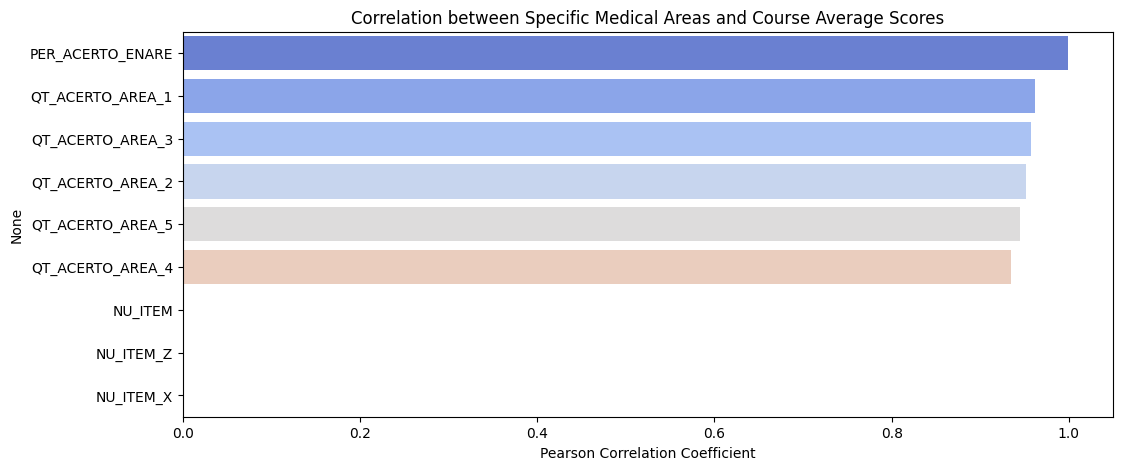

Selected features for the model: ['PER_ACERTO_ENARE', 'QT_ACERTO_AREA_1', 'QT_ACERTO_AREA_3', 'QT_ACERTO_AREA_2', 'QT_ACERTO_AREA_5', 'QT_ACERTO_AREA_4']


In [8]:
plt.figure(figsize=(12, 5))
correlations = df_ml[area_cols].corrwith(df_ml['avg_score_general']).sort_values(ascending=False)

sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Correlation between Specific Medical Areas and Course Average Scores')
plt.xlabel('Pearson Correlation Coefficient')
plt.show()

selected_features = correlations[correlations.abs() > 0.3].index.tolist()
print(f"Selected features for the model: {selected_features}")

## 5. Model Training: Linear Regression Baseline

In [9]:
X = df_ml[selected_features]
y = df_ml['avg_score_general']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Model Performance Metrics:")
print(f"R² Score (Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f} points")

Model Performance Metrics:
R² Score (Variance Explained): 0.9993
Mean Absolute Error (MAE): 0.1086 points


## 6. Expected vs. Reality Analysis (Focus: UFJF)

In [10]:
df_ufjf = df_ml[df_ml['is_ufjf'] == True]

for idx, row in df_ufjf.iterrows():
    campus_name = "Juiz de Fora (13103)" if row['CO_CURSO'] == 13103 else "Governador Valadares (5001167)"
    
    ufjf_features = pd.DataFrame([row[selected_features]], columns=selected_features)
    
    expected_score = model.predict(ufjf_features)[0]
    real_score = row['avg_score_general']
    residual = real_score - expected_score
    
    print(f"\n--- Analysis for Campus {campus_name} ---")
    print(f"Socioeconomic Expected Score: {expected_score:.2f}")
    print(f"Actual ENAMED 2025 Score:     {real_score:.2f}")
    print(f"Institutional Added Value (Residual): {residual:+.2f}")


--- Analysis for Campus Juiz de Fora (13103) ---
Socioeconomic Expected Score: 71.31
Actual ENAMED 2025 Score:     71.17
Institutional Added Value (Residual): -0.14

--- Analysis for Campus Governador Valadares (5001167) ---
Socioeconomic Expected Score: 75.27
Actual ENAMED 2025 Score:     75.51
Institutional Added Value (Residual): +0.24
